# Cosine Space Similarity Search

In [1]:
import chromadb
from PIL import Image
import matplotlib.pyplot as plt

## ChromaDB Client and Collections

In [2]:
# Connect to ChromaDB
client = chromadb.PersistentClient(path="../data/chroma_db")
client.list_collections()

[Collection(name=dataset3_without_augmentation),
 Collection(name=dataset3_images),
 Collection(name=val_clean_01),
 Collection(name=d3_clean_01),
 Collection(name=validation_images),
 Collection(name=dataset2_images)]

In [3]:
# Load original validation images
val_collection = client.get_collection("validation_images")
val_collection.peek(limit=1)

{'ids': ['0'],
 'embeddings': array([[0.01869522, 0.        , 0.05107115, ..., 0.06092875, 0.11964419,
         0.        ]], shape=(1, 2048)),
 'documents': ['..\\data\\valid\\images\\imagess_1000.jpg'],
 'uris': None,
 'included': ['metadatas', 'documents', 'embeddings'],
 'data': None,
 'metadatas': [None]}

In [4]:
dataset2_collection = client.get_collection("dataset2_images")
dataset2_collection.peek(limit=1)

{'ids': ['0'],
 'embeddings': array([[0.16972809, 0.00774314, 0.        , ..., 0.79465717, 0.        ,
         0.26859349]], shape=(1, 2048)),
 'documents': ['..\\data\\dataset_2_groups\\set_00_frame_00.jpg'],
 'uris': None,
 'included': ['metadatas', 'documents', 'embeddings'],
 'data': None,
 'metadatas': [{'frame': '00', 'set': '00'}]}

In [5]:
dataset3_collection = client.get_collection("dataset3_without_augmentation")

In [6]:
dataset3_collection.peek(limit=1)

{'ids': ['0'],
 'embeddings': array([[0.        , 0.        , 0.06523973, ..., 0.04720091, 0.        ,
         0.        ]], shape=(1, 2048)),
 'documents': ['..\\data\\images_dataset_3\\bangladeshi-biker-7444388_640.jpg'],
 'uris': None,
 'included': ['metadatas', 'documents', 'embeddings'],
 'data': None,
 'metadatas': [None]}

## Create function to compare datasets

In order to compare two datasets, we need to go through one dataset and compare each individual image to all the images in the second dataset.

In [7]:
def compare_collections(target_collection, query_collection, similarity_threshold_top=1, similarity_threshold_bottom=0.9):
    # loop through the target collection
    count_target = 0
    count_collection = target_collection.count()

    for idx in range(count_collection):
        # get the current target entry with embedding and document path and any metadata    
        target_result = target_collection.get(
            ids=[str(idx)], include=['embeddings', 'documents', 'metadatas']
        )
        target_embedding = target_result['embeddings'][0]
        target_path = target_result['documents'][0]
        target_metadatas = target_result['metadatas'][0]

        # query the query collection for similar images
        results = query_collection.query(
            query_embeddings=[target_embedding],
            n_results=5
        )

        # Split up results
        result_distances = results['distances'][0]
        result_paths = results['documents'][0]
        result_metadatas = results['metadatas'][0]

        # dist and similarity are inversly related (100% similarity = 0 distance/angle)
        dist_top = 1 - similarity_threshold_bottom
        if similarity_threshold_top == 1:
            # some distances are negative because they're so similar
            dist_bottom = -1
        else:
            dist_bottom = 1 - similarity_threshold_top

        # Filter results by threshold
        filtered_indices = [i for i, dist in enumerate(result_distances) 
                        if dist_bottom <= dist <= dist_top]
        
        # filter out the same path
        filtered_indices = [idx for idx in filtered_indices if result_paths[idx] != target_path]

        # If no matches, continue with next image to search
        if len(filtered_indices) == 0:
            continue
        
        # filter indices by set value if it exists (dataset 2 specific)
        if result_metadatas[0]:
            set_filtered_indices = []
            unique_set_values = []
            for idx in filtered_indices:
                item = result_metadatas[idx]
                # if target set is not none, check and skip if it matches
                if target_metadatas is not None:
                    if item['set'] == target_metadatas['set']:
                        continue
                if item['set'] not in unique_set_values:
                    unique_set_values.append(item['set'])
                    set_filtered_indices.append(idx)
            if len(set_filtered_indices) == 0:
                continue
            filtered_indices = set_filtered_indices

        # Display similar images
        n_similar = len(filtered_indices)
        n_cols = n_similar + 1  # +1 for image we are searching with
        fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))
        
        # Handle single subplot case
        if n_cols == 2:
            axes = [axes[0], axes[1]]
        
        # Display search image
        target_img = Image.open(target_path)
        target_title = target_path.split('\\')[-1]
        # if target_title is longer than 25 characters, continue in new line
        if len(target_title) > 25:
            target_title = f"{target_title[:25]}\n{target_title[25:]}"

        axes[0].imshow(target_img)
        axes[0].set_title(f"Searching from:\n{target_collection.name}\n[{target_title}]", fontweight='bold')
        axes[0].axis('off')
        
        # Display filtered similar images
        for plot_idx, result_idx in enumerate(filtered_indices):
            query_path = result_paths[result_idx]
            distance = result_distances[result_idx]
            similarity = (1 - distance) * 100  # Convert to similarity percentage
            
            query_img = Image.open(query_path)
            query_title = query_path.split('\\')[-1]
            # if query_title is longer than 25 characters, continue in new line
            if len(query_title) > 25:
                query_title = f"{query_title[:25]}\n{query_title[25:]}"
    
            axes[plot_idx + 1].imshow(query_img)
            axes[plot_idx + 1].set_title(f"Similarity: {similarity:.2f}%\n[{query_title}]")
            axes[plot_idx + 1].axis('off')
        
        plt.tight_layout()
        plt.show()
        count_target += 1

    print(f"Potential data leakage: {count_target}/{count_collection}")
    

## Compare Datasets for Data Leakage

### validation versus dataset 2

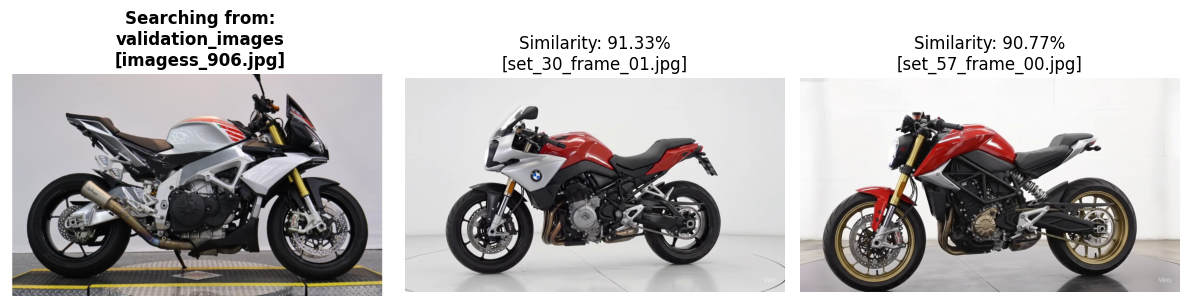

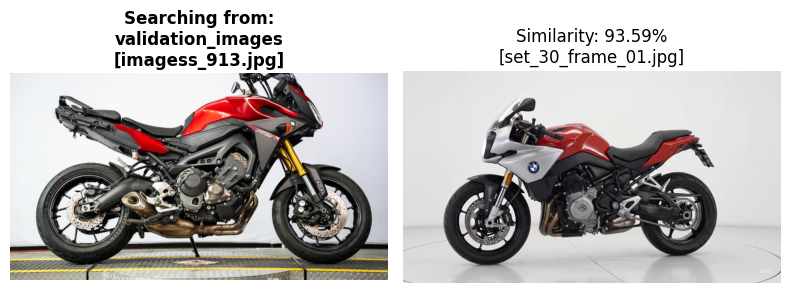

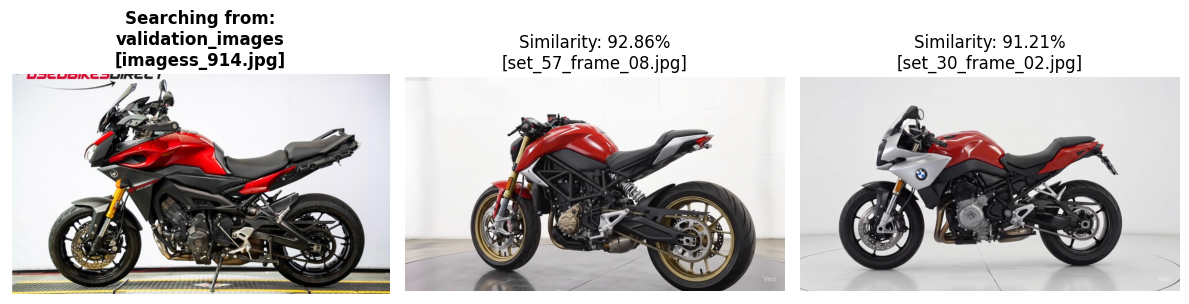

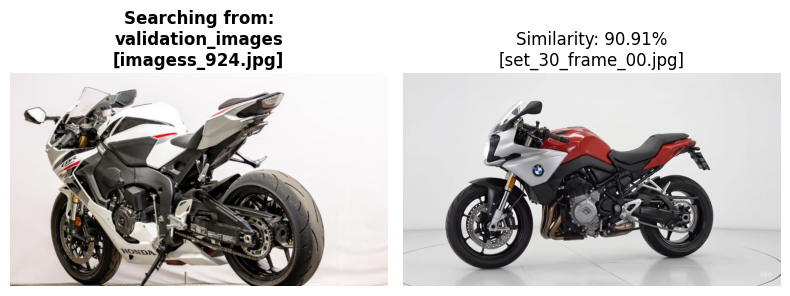

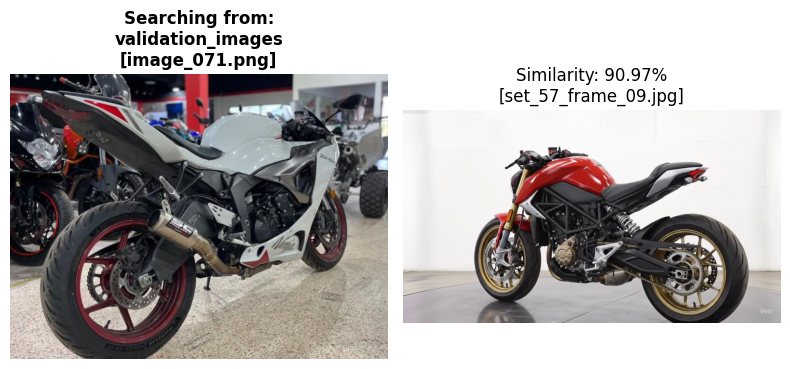

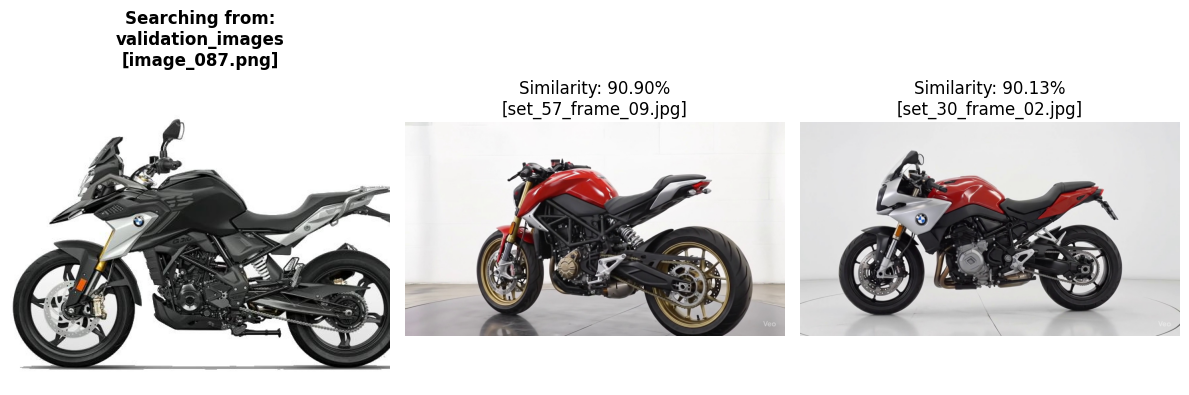

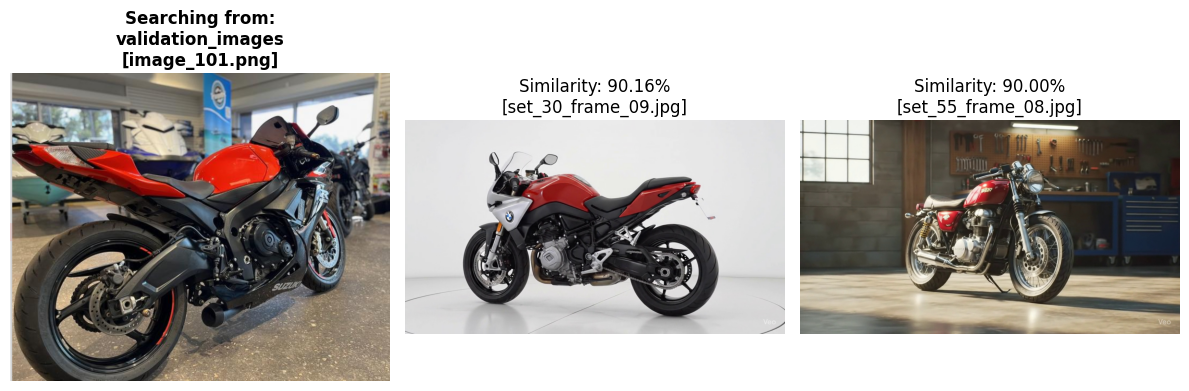

Potential data leakage: 7/1089


In [8]:
# 100% to 90% - default, most obvious offenders here
compare_collections(val_collection, dataset2_collection)

Dataset 2 doesn't contain any data leakage. It was also easier to verify, as technically there were only 99 videos generated, with 10 frames from each video.

### validation versus dataset 3

Dataset 3 contains all real images, which means we have a much higher likelyhood of data leakage, as our validation dataset is all real images as well.

#### 100-90%

First we'll check all similarity scores above 90%. These are all very highly likely to be data leakage, and we should spot cropped images too.

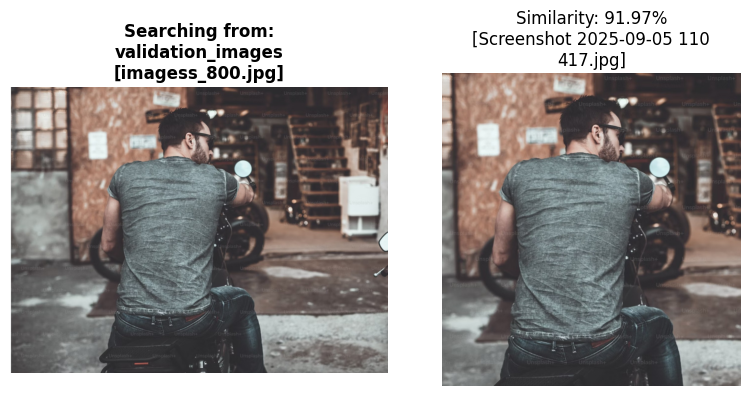

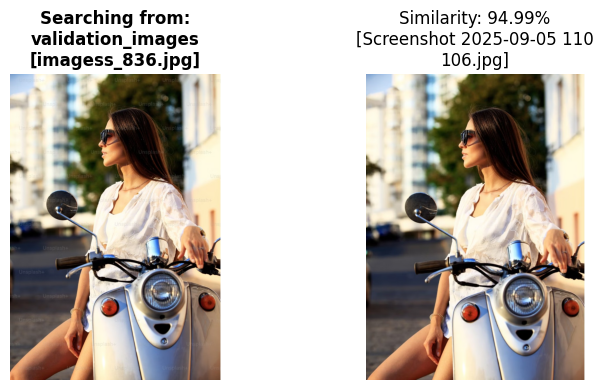

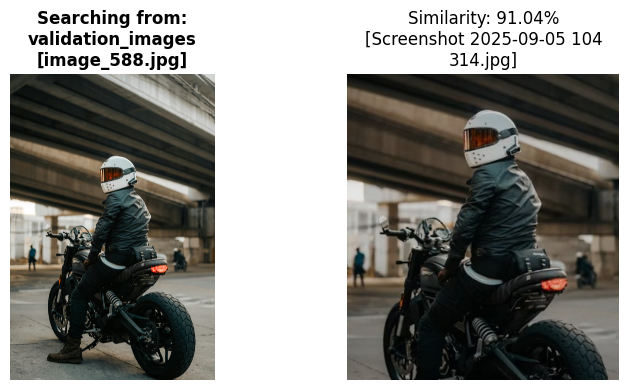

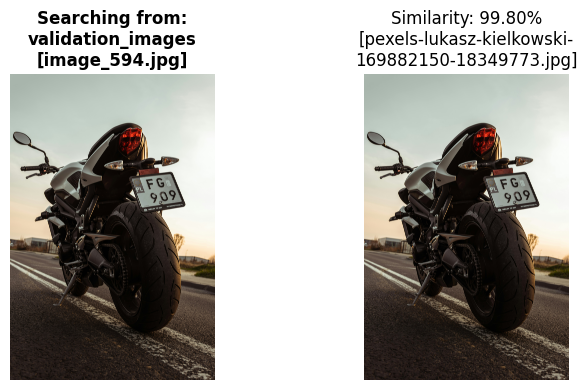

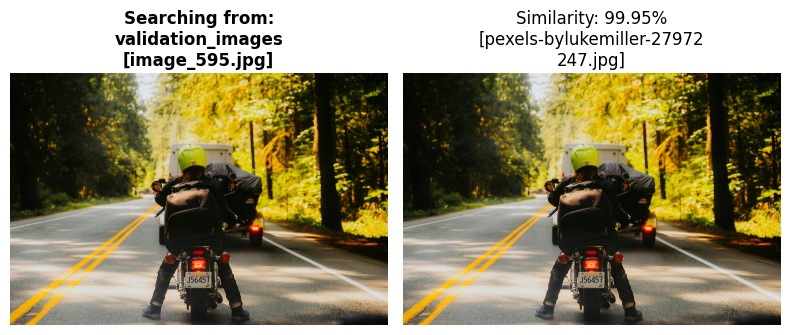

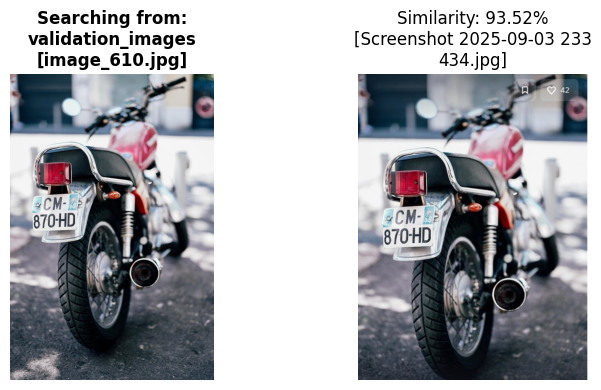

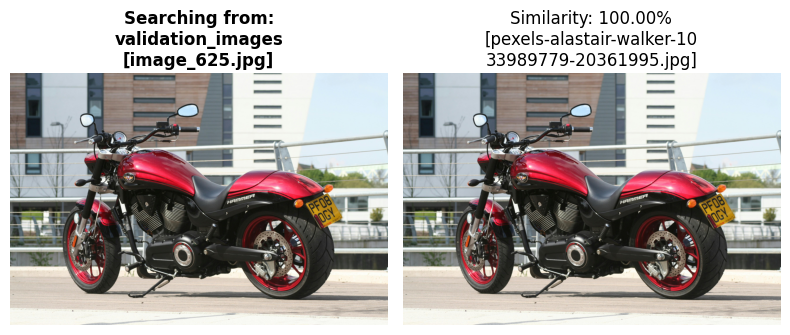

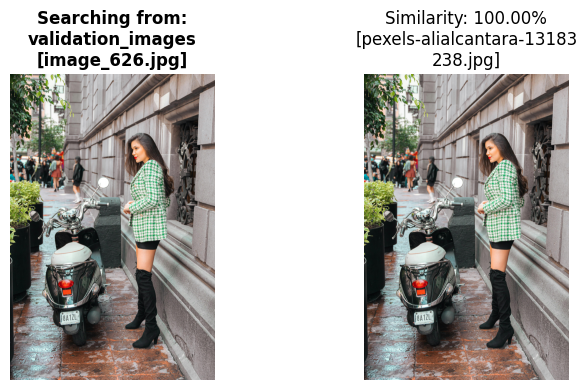

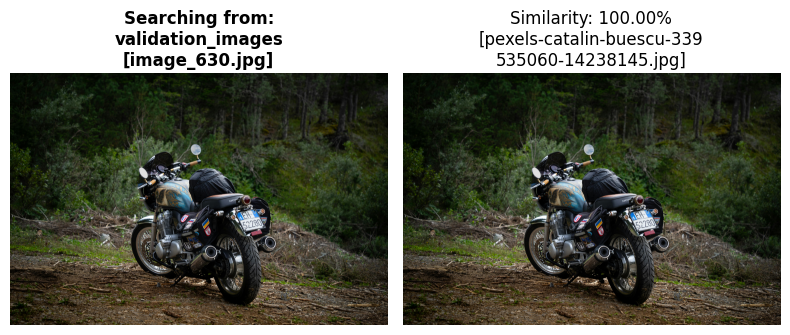

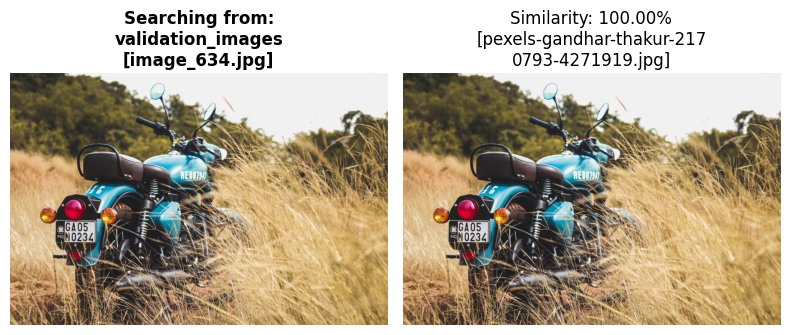

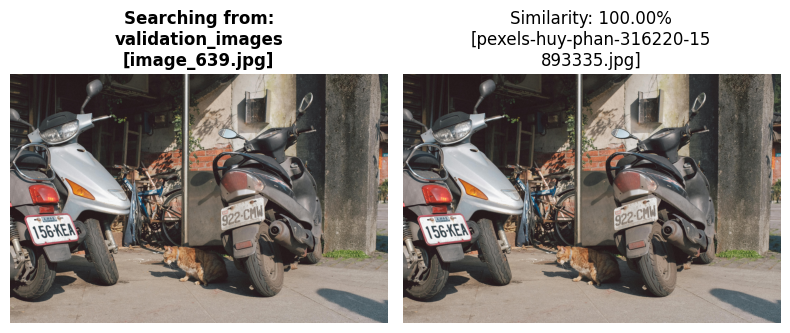

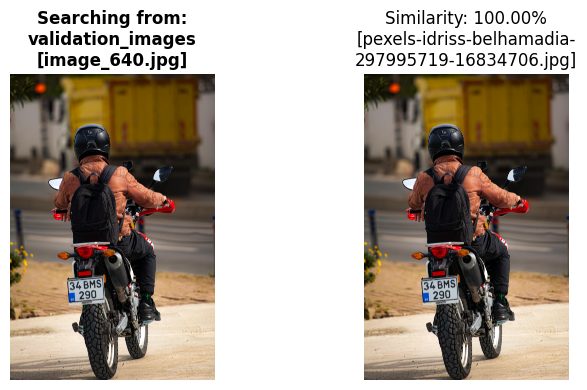

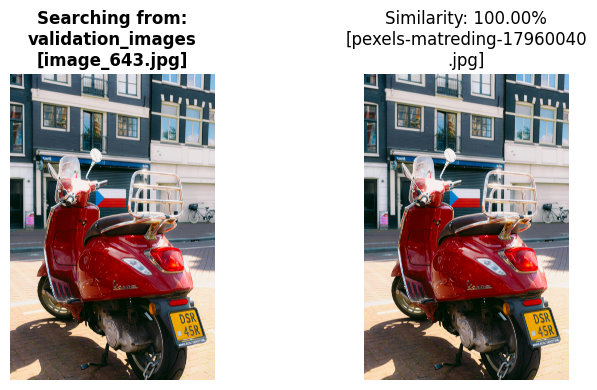

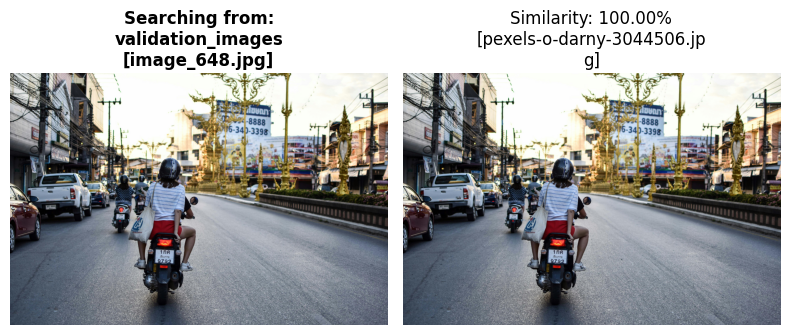

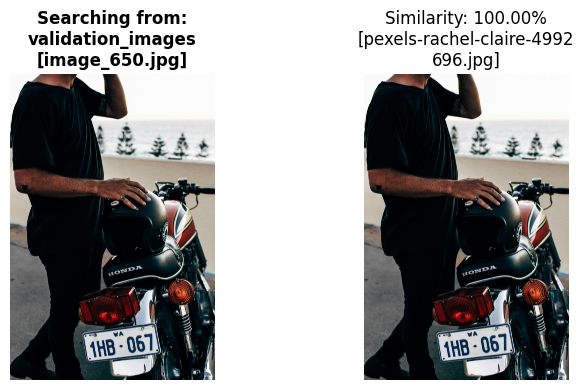

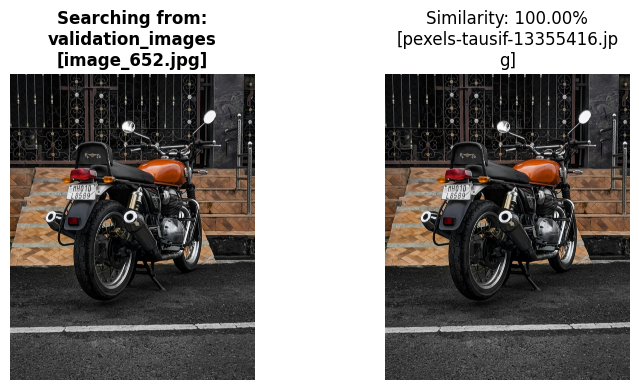

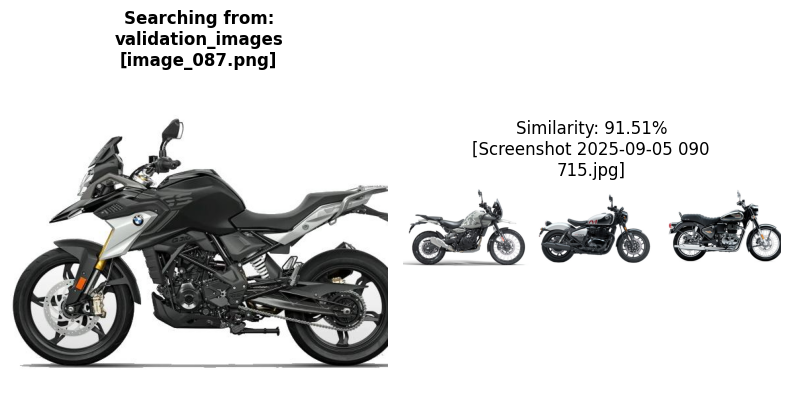

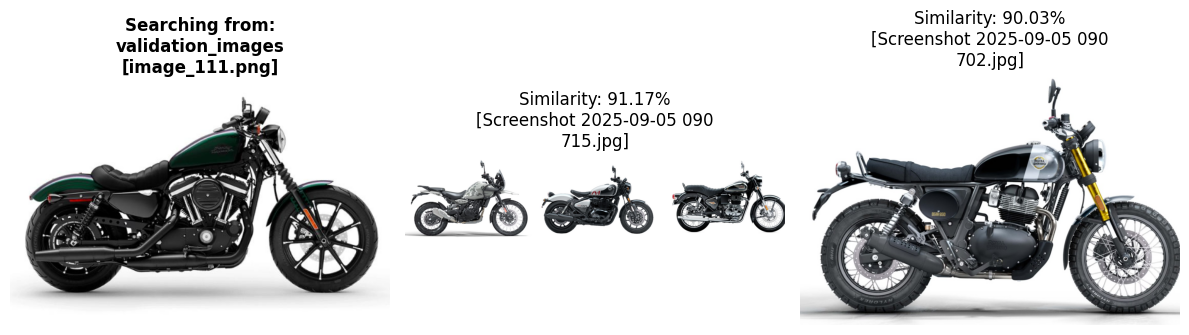

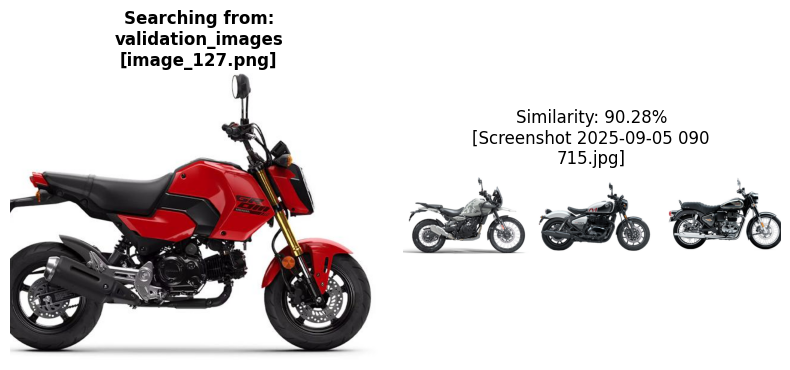

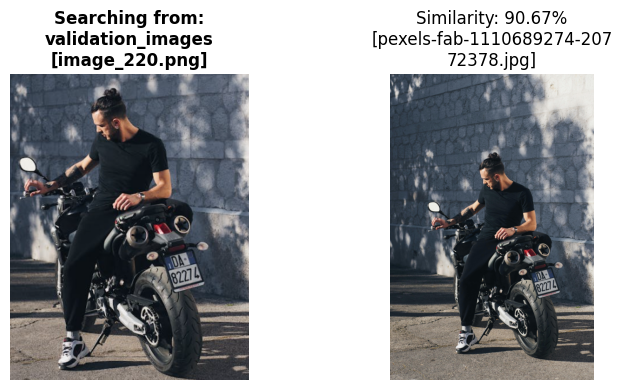

Potential data leakage: 20/1089


In [9]:
# 100% to 90% - default
compare_collections(val_collection, dataset3_collection)

Of the 20 that were above 90%, it appears that only 3 were not actually data leakage! We can see that some were exactly the same file, while others were cropped or altered, but we were still able to find them.

#### 90-80%

In [ ]:
# 90% to 80% - less obvious, catches cropped images
compare_collections(val_collection, dataset3_collection, similarity_threshold_top=0.9, similarity_threshold_bottom=0.8)

(Ommitting displayed images due to size of notebook).
Of the 125 here, only 7 were actually data leakage, and 3 of those we already identified in the previous pass.

#### 80-77.5%

(Ommitting displayed images due to size of notebook).
We still found 2 more in this range. The ratio between data leakage and not is continuing to drop. However, it is interesting to see several examples of images identified from the same photoshoot/set (for example image_733 and image_813), but as they are not the same image (or augmented from the same image) they are not considered data leakage.

#### 77.5-75%

(Ommitting displayed images due to size of notebook).
Only 1 found at this range, and it's one we already found previously.

#### 75-72.5% Similarity

(Ommitting displayed images due to size of notebook.)
No more data leakage detected. I think at this point it's fair to say we have caught any data leakage, and we have our list of items to remove.

Saved list of 24 total items to remove as "val_remove_paths.txt"